# Section 3: Logistic Regression versus Bayes Classifier

## Question 5: Discriminative versus Generative Models

### Part 1: Model Implementation and Baseline Comparison

#### Mathematical Foundation: Generative Bayes Classifiers

Unlike Logistic Regression, which directly finds a decision boundary (discriminative), Generative Bayes classifiers model the data distribution using Bayes' Theorem:
$$ P(Y=k|X) = \frac{P(X|Y=k)P(Y=k)}{P(X)} $$

To prevent numerical underflow, we use the log-posterior. Our ultimate goal is to calculate the total score for each class and pick the highest one (argmax):
$$ \arg\max_k \left( \ln P(Y=k) + \ln P(X|Y=k) \right) $$

**1. Class Prior $\ln P(Y=k)$:** 
This is the baseline probability of each class, calculated simply by counting the proportion of samples in class $k$.

**2. Log-Likelihood $\ln P(X|Y=k)$ (The Strong Assumption & Formula Variations):**
Generative models apply a "strong assumption" that the features follow a Multivariate Gaussian (Normal) distribution. Depending on how we assume the features interact, the calculation of the log-likelihood transforms into **three specific mathematical formulas**:

*   **Naive Bayes:** 
    Assumes all features are perfectly independent. The complex covariance matrix $\Sigma$ is shattered, leaving only individual variances $\sigma_{kj}^2$. Matrix multiplication is abandoned, and we simply sum up the individual features.
    **Formula:**
    $$ \ln P(X|Y=k) \propto - \frac{1}{2} \sum_{j=1}^d \left( \ln(2\pi\sigma_{kj}^2) + \frac{(x_j - \mu_{kj})^2}{\sigma_{kj}^2} \right) $$

*   **Shared Covariance (LDA):** 
    Assumes features are correlated, but all classes share the **exact same** covariance matrix $\Sigma$. Because the determinant term $\ln|\Sigma|$ is identical for all classes, it is effectively a useless constant when comparing scores. Therefore, it is entirely dropped from the formula, leaving only the Mahalanobis Distance.
    **Formula:**
    $$ \ln P(X|Y=k) \propto - \frac{1}{2} (X-\mu_k)^T \Sigma^{-1} (X-\mu_k) $$

*   **Class-Specific Covariance (QDA):** 
    The most "complete" version. Assumes each class $k$ has its own unique correlation pattern, requiring a separate full covariance matrix $\Sigma_k$ for every class. Because each class's matrix volume is different, the determinant term must be kept.
    **Formula:**
    $$ \ln P(X|Y=k) \propto -\frac{1}{2} \ln |\Sigma_k| - \frac{1}{2} (X-\mu_k)^T \Sigma_k^{-1} (X-\mu_k) $$

In [1]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


In [2]:
# 1. Load the breast cancer dataset
features, labels = load_breast_cancer(return_X_y=True)

# 2. Split the data into 80% training and 20% test sets using random seed 5201
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=5201)

# 3. As required, use only the training data (X_train) to compute the mean and standard deviation
train_mean = np.mean(X_train, axis=0)
train_std = np.std(X_train, axis=0)

# 4. Standardise the training and test sets using the mean and standard deviation computed from the training set
X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

In [3]:
class CustomGenerativeClassifiers:
    def __init__(self, model_type="naive_bayes", epsilon_for_stability=1e-6):
        self.model_type = model_type
        self.epsilon_for_stability = epsilon_for_stability 
        
    def fit(self, X, y):
        self.unique_classes_ = np.unique(y)
        num_samples, num_features = X.shape
        
        # Prepare storage
        self.class_probabilities_ = np.zeros(len(self.unique_classes_))     # After execution: self.class_probabilities_ = [0.0, 0.0]; index 0 is reserved for the benign-class probability and index 1 for the malignant-class probability, with the actual values computed below
        # [
        #   [0.0, 0.0],  <-- this row is reserved for class 0 (benign), storing [mean of feature 1, mean of feature 2]
        #   [0.0, 0.0]   <-- this row is reserved for class 1 (malignant), storing [mean of feature 1, mean of feature 2]
        # ]
        self.feature_means_per_class_ = np.zeros((len(self.unique_classes_), num_features))         
        
        # ==========================================
        # Step 1: Fill the reserved storage
        # ==========================================
        for idx, current_class in enumerate(self.unique_classes_):
            # For example, if current_class is 0 (benign), select only the data for benign patients
            X_current_class = X[y == current_class]
            
            # Corresponding formula: prior probability P(Y=k) = number of samples in the class / total number of samples
            # Compute the proportion of benign patients and store it at index 0 of class_probabilities_
            self.class_probabilities_[idx] = X_current_class.shape[0] / num_samples
            
            # Preparation for the formula: to compute likelihood P(X|Y=k) later, first calculate each feature mean. This gives the Gaussian centre μ for substitution into the likelihood formula
            # [idx, :] selects row idx and fills it with the complete vector of computed means
            # Compute the feature means for the benign patients and store them in row 0 of feature_means_per_class_
            self.feature_means_per_class_[idx, :] = np.mean(X_current_class, axis=0)
            
        # ==========================================
        # Step 2: Compute variance or covariance matrices, continuing to allocate and fill the required storage
        # This block prepares the underlying parameters needed to calculate the likelihood P(X|Y=k)
        # ==========================================
        if self.model_type == "naive_bayes":
            # Prepare storage: as for the means, create a two-row table for the variances
            # [
            #   [0.0, 0.0],  <-- this row is reserved for class 0 (benign), storing [variance of feature 1, variance of feature 2]
            #   [0.0, 0.0]   <-- this row is reserved for class 1 (malignant), storing [variance of feature 1, variance of feature 2]
            # ]
            self.feature_variances_per_class_ = np.zeros((len(self.unique_classes_), num_features))
            
            for idx, current_class in enumerate(self.unique_classes_):
                # Compute the variance of each feature for the current class k, such as benign, and store it in the corresponding row. Add epsilon to prevent a zero variance from causing errors later
                self.feature_variances_per_class_[idx, :] = np.var(X[y == current_class], axis=0) + self.epsilon_for_stability
                
        elif self.model_type == "shared_covariance":
            # Prepare storage: all samples share one feature-relationship table, represented by a single 2x2 covariance matrix
            # For two features, this creates a 2x2 table:
            # [
            #   [0.0, 0.0],  <-- relationship of feature 1 with feature 1, and feature 1 with feature 2
            #   [0.0, 0.0]   <-- relationship of feature 2 with feature 1, and feature 2 with feature 2
            # ]
            self.shared_covariance_matrix_ = np.zeros((num_features, num_features))
            
            for idx, current_class in enumerate(self.unique_classes_):
                X_current_class = X[y == current_class]
                # Compute the covariance matrices for the benign and malignant classes separately, then combine them according to class proportions into one shared matrix
                self.shared_covariance_matrix_ += np.cov(X_current_class.T, bias=True) * (X_current_class.shape[0] / num_samples)
            
            self.shared_covariance_matrix_ += np.eye(num_features) * self.epsilon_for_stability    # Add epsilon to prevent numerical problems, such as a row containing identical values
            # Compute its inverse matrix for the next calculation
            self.inverse_shared_covariance_ = np.linalg.pinv(self.shared_covariance_matrix_)
            
        elif self.model_type == "class_specific_covariance":
            # Prepare storage using empty lists [] rather than zero-filled placeholders
            self.covariance_matrices_per_class_ = []  # Will store [benign covariance matrix, malignant covariance matrix]
            self.inverse_covariances_per_class_ = []  # Will store [benign inverse matrix, malignant inverse matrix]
            self.log_determinants_per_class_ = []     # Will store [benign log-determinant, malignant log-determinant]
            
            for idx, current_class in enumerate(self.unique_classes_):
                # Formula: covariance for the current class Σ_k = Cov(X_k) + ε*I, where Σ_k denotes the covariance matrix for class k
                cov_matrix = np.cov(X[y == current_class].T, bias=True) + np.eye(num_features) * self.epsilon_for_stability
                self.covariance_matrices_per_class_.append(cov_matrix)
                # Formula: compute the inverse matrix Σ_k^-1
                self.inverse_covariances_per_class_.append(np.linalg.pinv(cov_matrix))
                # Formula: compute the log-determinant ln|Σ_k|
                _, singular_values, _ = np.linalg.svd(cov_matrix)        # Singular value decomposition
                self.log_determinants_per_class_.append(np.sum(np.log(singular_values)))

    def predict(self, X):
        log_probabilities = np.zeros((X.shape[0], len(self.unique_classes_)))    # Create a score table with 100 rows and 2 columns

        for idx, current_class in enumerate(self.unique_classes_):    # idx is the class index
            
            log_prior = np.log(self.class_probabilities_[idx])    # log_prior corresponds to the log prior probability ln P(Y=k)
            difference_from_mean = X - self.feature_means_per_class_[idx]    # difference_from_mean corresponds to the difference vector (X - μ_k)
            
            # ==========================================
            # Step 3: Compute the log posterior probability ln P(Y=k|X)
            # ==========================================
            if self.model_type == "naive_bayes":
                variances = self.feature_variances_per_class_[idx]
                # Full formula: ln P(Y=k) - 0.5 * sum( ln(2*pi*σ_kj^2) + (X - μ_k)^2 / σ_kj^2 )
                # Term-by-term correspondence:
                # 1. log_prior ----------------------------> ln P(Y=k)
                # 2. np.log(2 * np.pi * variances) --------> ln(2*pi*σ_kj^2)
                # 3. (difference_from_mean ** 2) ----------> (X - μ_k)^2
                # 4. / variances --------------------------> / σ_kj^2
                # log_probabilities = [
                #    [0.0, 0.0],  <-- scoring slots for patient 1: [benign score, malignant score]
                #    [0.0, 0.0],  <-- scoring slots for patient 2: [benign score, malignant score]
                #    [0.0, 0.0]   <-- scoring slots for patient 3: [benign score, malignant score]
                # ] filled one column at a time for the benign and malignant classes
                log_probabilities[:, idx] = log_prior - 0.5 * np.sum(
                    np.log(2 * np.pi * variances) + (difference_from_mean ** 2) / variances, axis=1
                )
                
            elif self.model_type == "shared_covariance":
                # Full formula: ln P(Y=k) - 0.5 * (X - μ_k)^T * Σ^-1 * (X - μ_k)
                # Term-by-term correspondence:
                # 1. difference_from_mean -----------------> (X - μ_k)
                # 2. self.inverse_shared_covariance_ ------> Σ^-1 
                # 3. Multiply the two sides and sum -------------------------> the Mahalanobis distance: (X - μ_k)^T * Σ^-1 * (X - μ_k)
                distance_term = np.sum(difference_from_mean @ self.inverse_shared_covariance_ * difference_from_mean, axis=1)
                
                log_probabilities[:, idx] = log_prior - 0.5 * distance_term    # log_prior corresponds to ln P(Y=k), and distance_term to the distance component that follows
                
            elif self.model_type == "class_specific_covariance":
                # Full formula: ln P(Y=k) - 0.5 * ln|Σ_k| - 0.5 * (X - μ_k)^T * Σ_k^-1 * (X - μ_k)
                # Term-by-term correspondence:
                # 1. self.inverse_covariances_per_class_[idx] -> Σ_k^-1
                distance_term = np.sum(difference_from_mean @ self.inverse_covariances_per_class_[idx] * difference_from_mean, axis=1)
                
                # 2. log_prior ----------------------------> ln P(Y=k)
                # 3. self.log_determinants_per_class_[idx] -> ln|Σ_k| (log-determinant of the covariance matrix)
                # 4. distance_term ------------------------> (X - μ_k)^T * Σ_k^-1 * (X - μ_k)
                log_probabilities[:, idx] = log_prior - 0.5 * (self.log_determinants_per_class_[idx] + distance_term)
                
        # Finally compare the scores for all classes and select the class with the highest score using argmax
        return self.unique_classes_[np.argmax(log_probabilities, axis=1)]

In [4]:
# 1. Logistic regression classifier using the built-in sklearn implementation
logistic_regression_model = LogisticRegression()
logistic_regression_model.fit(X_train_scaled, y_train)

# 2. Naive Bayes classifier with a class-specific diagonal covariance matrix
naive_bayes_model = CustomGenerativeClassifiers(model_type="naive_bayes")
naive_bayes_model.fit(X_train_scaled, y_train)

# 3. Gaussian Bayes classifier with a shared full covariance matrix
gaussian_bayes_shared_cov = CustomGenerativeClassifiers(model_type="shared_covariance")
gaussian_bayes_shared_cov.fit(X_train_scaled, y_train)

# 4. Gaussian Bayes classifier with class-specific full covariance matrices
gaussian_bayes_specific_cov = CustomGenerativeClassifiers(model_type="class_specific_covariance")
gaussian_bayes_specific_cov.fit(X_train_scaled, y_train)

# Store the models in a dictionary for convenient iteration and result reporting
models_dict = {
    "Logistic Regression": logistic_regression_model,
    "Naive Bayes (Diagonal Covariance)": naive_bayes_model,
    "Gaussian Bayes (Shared Full Covariance)": gaussian_bayes_shared_cov,
    "Gaussian Bayes (Class-Specific Full Covariance)": gaussian_bayes_specific_cov
}

# Display training and test accuracy
for model_name, trained_model in models_dict.items():
    train_accuracy = accuracy_score(y_train, trained_model.predict(X_train_scaled))
    test_accuracy = accuracy_score(y_test, trained_model.predict(X_test_scaled))
    print(f"{model_name}:")
    print(f"  Training Accuracy: {train_accuracy:.4f}")
    print(f"  Test Accuracy:     {test_accuracy:.4f}\n")

Logistic Regression:
  Training Accuracy: 0.9890
  Test Accuracy:     0.9649

Naive Bayes (Diagonal Covariance):
  Training Accuracy: 0.9451
  Test Accuracy:     0.9035

Gaussian Bayes (Shared Full Covariance):
  Training Accuracy: 0.9670
  Test Accuracy:     0.9123

Gaussian Bayes (Class-Specific Full Covariance):
  Training Accuracy: 0.9780
  Test Accuracy:     0.9298



#### Baseline Comparison Discussion

Based on the baseline results, **Logistic Regression performs best on the fixed test set** (Test Accuracy: 0.9649), outperforming all generative Bayes models. 

This outcome relates to model assumptions and data availability. Generative models make strict assumptions about the underlying data distribution (i.e., assuming features follow a perfect Gaussian distribution). If the real-world breast cancer data violates these assumptions, discriminative models like Logistic Regression—which make fewer assumptions and focus purely on optimizing the decision boundary—tend to generalize better. 

Furthermore, estimating covariance matrices is highly sensitive to the amount of training data. The dataset has 30 features ($d=30$). While estimating a diagonal covariance (Naive Bayes) is simple, estimating a class-specific full covariance matrix requires computing $\frac{d(d+1)}{2} = 465$ independent parameters per class. With only around 455 training samples available in the 80% split, the data is insufficient to reliably estimate these complex class-specific matrices without adding stabilization (epsilon), making the highly-parameterized generative models more prone to instability compared to Logistic Regression.

### Part 2: Learning-Curve Experiment

In [5]:
# ==========================================================
# Core task: determine whether model performance improves as the number of training examples increases
# Method: evaluate increasing training-set sizes, repeating each size 10 times and averaging the scores
# ==========================================================

N_values = [10, 20, 40, 80, 160, 320, 400]  # The seven required training-set sizes
repetitions = 10                            # Repeat the sampling experiment 10 times for each training-set size
model_names = list(models_dict.keys())      # Get the names of the four candidate models

# Prepare an overall results record for each model's final mean score and variability
results = {
    "train_mean": {m: [] for m in model_names}, # Store mean training accuracy
    "train_std": {m: [] for m in model_names},  # Store variability in training accuracy
    "test_mean": {m: [] for m in model_names},  # Store mean test accuracy
    "test_std": {m: [] for m in model_names},   # Store variability in test accuracy
}

# ==========================================================
# Outer loop: process the training-set sizes in order, for example 10 and then 20
# ==========================================================
for N in N_values:
    train_acc_temp = {m: [] for m in model_names}  # Temporary record of the 10 training scores for the current sample size
    test_acc_temp = {m: [] for m in model_names}   # Temporary record of the 10 test scores for the current sample size
    
    # ==========================================================
    # Inner loop: draw samples and evaluate 10 times at the current training-set size
    # ==========================================================
    for r in range(repetitions):
        seed = 5202 + 100 * r + N                  # Follow the assignment formula exactly to generate a distinct random-sampling seed for each repetition
        
        # Using the seed above, draw N training examples from the full pool, ensuring that both benign and malignant classes are represented
        X_subset, _, y_subset, _ = train_test_split(
            X_train, y_train, train_size=N, 
            random_state=seed, stratify=y_train
        )
        
        subset_mean = np.mean(X_subset, axis=0)    # Important: compute the mean using only these N training examples to prevent data leakage
        subset_std = np.std(X_subset, axis=0)      # Important: compute the standard deviation using only these N training examples to prevent data leakage
        
        X_subset_scaled = (X_subset - subset_mean) / subset_std        # Standardise the N training examples
        X_test_fixed_scaled = (X_test - subset_mean) / subset_std      # Standardise the fixed test set using the same training-derived statistics
        
        # Evaluate each of the four models in turn
        for name in model_names:
            # Reinitialise every model before each run
            # Otherwise, it may retain information from the previous run and invalidate the results
            if name == "Logistic Regression":
                current_model = LogisticRegression()
            elif name == "Naive Bayes (Diagonal Covariance)":
                current_model = CustomGenerativeClassifiers(model_type="naive_bayes")
            elif name == "Gaussian Bayes (Shared Full Covariance)":
                current_model = CustomGenerativeClassifiers(model_type="shared_covariance")
            else:
                current_model = CustomGenerativeClassifiers(model_type="class_specific_covariance")
                
            current_model.fit(X_subset_scaled, y_subset)   # Fit the model on the N training examples
            
            train_pred = current_model.predict(X_subset_scaled)      # Measure performance on the N training examples
            test_pred = current_model.predict(X_test_fixed_scaled)   # Measure performance on the unseen test set
            
            # Record the accuracy scores in the temporary results
            train_acc_temp[name].append(accuracy_score(y_subset, train_pred))
            test_acc_temp[name].append(accuracy_score(y_test, test_pred))
            
    # ==========================================================
    # After all 10 repetitions, compute the summary statistics and add the means to the overall results
    # ==========================================================
    for name in model_names:
        results["train_mean"][name].append(np.mean(train_acc_temp[name])) # Compute mean training accuracy across 10 repetitions
        results["train_std"][name].append(np.std(train_acc_temp[name]))   # Compute variability in training accuracy across 10 repetitions
        results["test_mean"][name].append(np.mean(test_acc_temp[name]))   # Compute mean test accuracy across 10 repetitions
        results["test_std"][name].append(np.std(test_acc_temp[name]))     # Compute variability in test accuracy across 10 repetitions

### Part 3: Learning-Curve Analysis

#### Learning-Curve Analysis

Based on the learning curves, the following patterns are observed:

* **Training Accuracy:** Training accuracy generally decreases as $N$ increases. At $N=10$, all four models achieve 1.000 training accuracy. At $N=400$, the accuracies decrease to 0.990 for Logistic Regression, 0.945 for Naive Bayes, 0.966 for the shared-covariance model, and 0.979 for the class-specific model.

* **Test Accuracy:** Test accuracy generally improves with $N$, but not consistently for every model. Logistic Regression increases from 0.866 at $N=10$ to 0.965 at $N=400$. The class-specific model initially declines from 0.716 at $N=10$ to 0.545 at $N=40$ and 0.529 at $N=80$, before recovering to 0.918 at $N=400$.

* **Accuracy Gap:** The training-test gap is largest at small $N$, particularly for the full-covariance models, which achieve perfect training accuracy but substantially lower test accuracy. The gap narrows as more training data become available, indicating reduced overfitting.

* **Variability at Small $N$:** At $N=10$, Naive Bayes has the greatest test-accuracy variability (standard deviation 0.096), followed by the class-specific model (0.071) and shared-covariance model (0.069). Logistic Regression is the most stable (0.050). Estimating variance and covariance parameters from very small samples is unreliable, causing the generative models to vary across repetitions.

* **Performance Differences:** Differences between the models become smaller as $N$ increases. At $N=400$, Logistic Regression remains the best model with test accuracy 0.965, while the generative models achieve between 0.904 and 0.918.

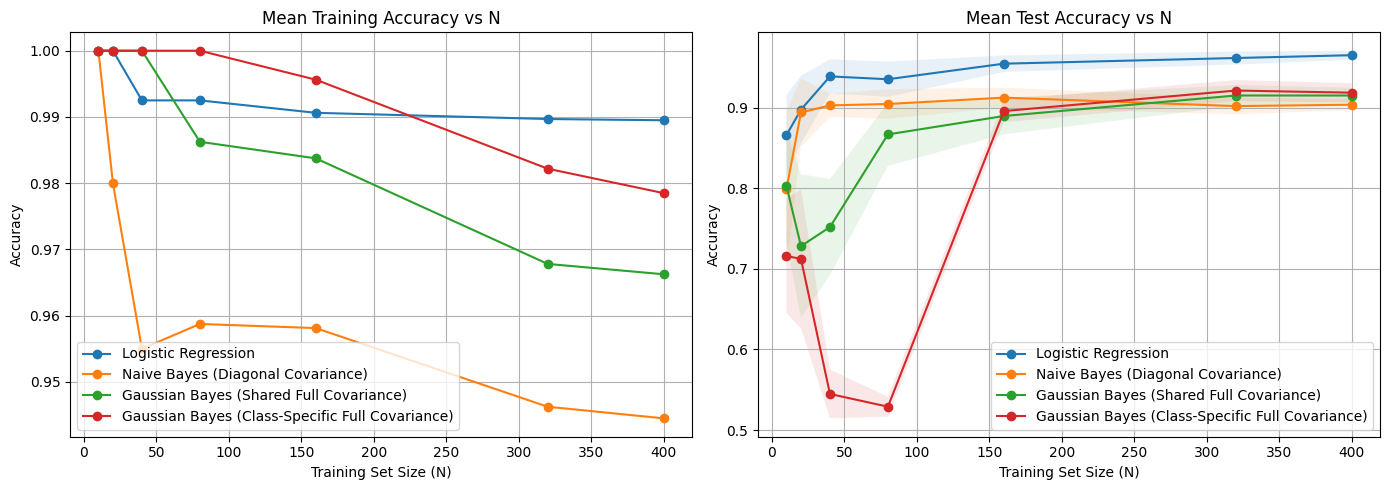

In [6]:
# Prepare a figure with one row and two columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name in model_names:
    # Panel 1: Mean training accuracy versus sample size N
    ax1.plot(N_values, results["train_mean"][name], marker='o', label=name)
    
    # Panel 2: Mean test accuracy, with fill_between shading one standard deviation above and below the mean
    test_means = np.array(results["test_mean"][name])
    test_stds = np.array(results["test_std"][name])
    
    ax2.plot(N_values, test_means, marker='o', label=name)
    ax2.fill_between(N_values, test_means - test_stds, test_means + test_stds, alpha=0.1)

# Set the title and axes for the training-set plot on the left
ax1.set_title("Mean Training Accuracy vs N")
ax1.set_xlabel("Training Set Size (N)")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True)

# Set the title and axes for the test-set plot on the right
ax2.set_title("Mean Test Accuracy vs N")
ax2.set_xlabel("Training Set Size (N)")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

# Automatically adjust the layout and display the figure
plt.tight_layout()
plt.show()

### Part 4: Model Complexity and Conceptual Comparison



**Parameter Counts ($d=30, K=2$):** Covariance matrix symmetry halves the required parameters to $d(d+1)/2 = 465$.

* **Logistic Regression:** $d + 1 =$ **31**.
* **Naive Bayes:** $1 + 2d + 2d =$ **121**.
* **Shared Covariance:** $1 + 2d + 465 =$ **526**.
* **Class-Specific:** $1 + 2d + 2(465) =$ **991**.

**Recommendations & Discussion:**
For a **small dataset** ($N=20$), I recommend Naive Bayes or Logistic Regression. As shown in Part 3, they maintain stable test accuracy (~0.90). For a **large dataset** ($N=400$), Logistic Regression or Class-Specific Bayes are preferable, converging to the highest test accuracies.

Models with fewer parameters and stronger assumptions (Naive Bayes) exhibit high bias but low variance. Conversely, highly parameterized models (Class-Specific) have low bias but high variance.

When data is scarce, estimating 991 parameters causes flexible models to memorize noise. Strong assumptions prevent this by restricting the hypothesis space. This perfectly explains why Class-Specific test accuracy plummets around $N=40-80$ despite perfect training accuracy.

However, abundant data allows complex models to reliably estimate their parameters, significantly reducing variance. Their inherently low bias then captures complex boundaries, overtaking simpler models like Naive Bayes, which plateau (underfit) due to rigid assumptions.
